<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Introducción a la IA Generativa 🎨✨
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4f46e5; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 03 • Ética y el Nuevo Paradigma de la IA
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Introduccion%20a%20la%20Inteligencia%20Artificial/03%20-%20Etica%20y%20el%20Nuevo%20Paradigma%20de%20la%20IA/02_Introduccion_a_la_IA_Generativa.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

## 1. IA Discriminativa vs. IA Generativa 🔀

La inmensa mayoría de los modelos de Machine Learning "clásicos" son **discriminativos** (o predictivos): aprenden a trazar una frontera entre categorías, o a predecir un valor numérico a partir de entradas. La **IA generativa**, en cambio, aprende la **distribución de probabilidad completa** de los datos de entrenamiento, y con ella puede **producir contenido nuevo** que nunca existió literalmente en el conjunto de entrenamiento, pero que es estadísticamente plausible.

| Aspecto | IA Discriminativa / Predictiva | IA Generativa |
|---|---|---|
| **Pregunta que responde** | "¿A qué categoría pertenece X?" / "¿Cuál es el valor de Y dado X?" | "¿Cómo se ve/suena/lee un ejemplo plausible de esta distribución?" |
| **Qué modela** | La frontera de decisión, o $P(Y \mid X)$ | La distribución completa de los datos, $P(X)$ (o $P(X \mid \text{prompt})$) |
| **Salida típica** | Una etiqueta, una probabilidad, un número | Texto, imagen, audio, video o código enteramente nuevos |
| **Ejemplos clásicos** | Regresión logística, árboles de decisión, SVM | Modelos de lenguaje (GPT), modelos de difusión (Stable Diffusion, DALL·E) |
| **Riesgo característico** | Sesgo en la predicción | Alucinaciones, *deepfakes*, contenido no verificable |

## 2. ¿Qué Puede Generar la IA Generativa? 🎁

| Tipo de contenido | Técnica dominante | Ejemplos de familias de modelos (nivel conceptual) |
|---|---|---|
| **Texto** | Transformers autoregresivos | Familia GPT, Llama, Claude, Gemini |
| **Imagen** | Modelos de difusión / GANs | Stable Diffusion, DALL·E, Midjourney |
| **Audio / Música** | Modelos de difusión y autoregresivos sobre espectrogramas | MusicLM, motores de texto-a-voz neuronal |
| **Video** | Extensión temporal de modelos de difusión | Sora, Runway |
| **Código** | Transformers entrenados sobre repositorios de código | GitHub Copilot, Code Llama |

> Este cuaderno describe estas familias a **nivel conceptual únicamente** — no se usa ni se replica código propietario de ningún proveedor comercial. El laboratorio de la Sección 4 construye, desde cero, un modelo generativo de juguete para ilustrar el principio subyacente.

## 3. Cómo Funcionan a Alto Nivel 🔧

Los modelos de lenguaje modernos son, en esencia, sistemas que predicen "cuál es la palabra (o *token*) más probable que sigue", entrenados sobre cantidades masivas de texto. Al encadenar miles de estas predicciones, una a la vez, emerge un texto coherente — este mecanismo se llama **generación autoregresiva**.

Los modelos de imagen por difusión funcionan con un principio distinto: aprenden el proceso **inverso al ruido**. Parten de ruido puro (como estática de televisor) y, paso a paso, lo van "limpiando" hacia una imagen coherente con el texto de entrada (*prompt*), en un proceso llamado *denoising* iterativo.

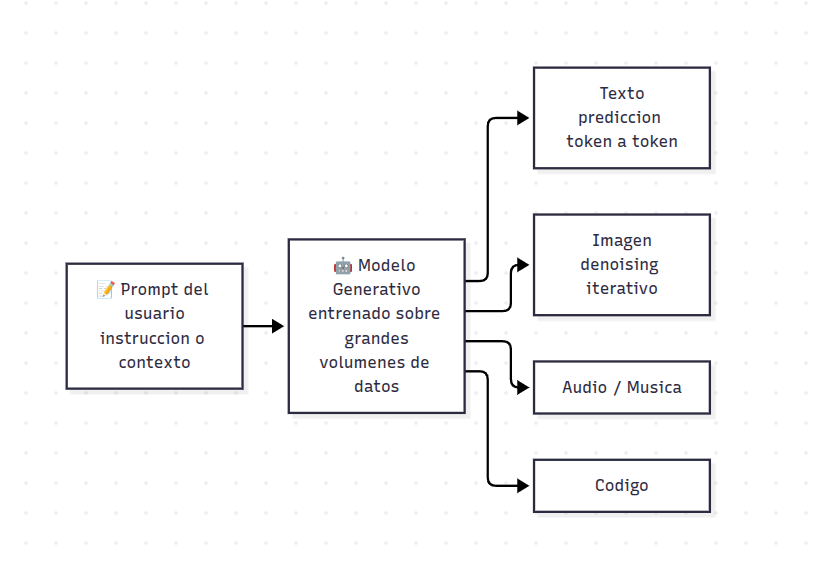

## 4. Laboratorio: Un Generador de Texto Probabilístico Mínimo (Cadena de Markov) 💻

Sin usar ningún modelo de lenguaje real ni ninguna API externa, vamos a construir el ancestro conceptual más simple de un generador de texto: una **cadena de Markov de orden 2**, entrenada sobre un corpus minúsculo definido directamente en el código. La idea central —predecir la siguiente palabra según lo que ya se generó, usando probabilidades aprendidas de datos— es la misma idea de fondo detrás de los modelos de lenguaje modernos, aunque estos usan arquitecturas (*Transformers*) y escalas de datos radicalmente más sofisticadas.

In [ ]:
import random

# Pequeño corpus de entrenamiento embebido directamente en el código
# (en un LLM real, este corpus tendría billones de palabras; aquí usamos
# un puñado de frases para que el mecanismo sea 100% transparente)
corpus = """
la inteligencia artificial aprende patrones a partir de datos
el aprendizaje profundo usa redes neuronales con muchas capas
la inteligencia artificial generativa produce contenido nuevo
el aprendizaje automatico aprende patrones sin reglas explicitas
la inteligencia artificial etica exige transparencia y responsabilidad
""".split()

# Construimos un modelo de Markov de orden 2: para cada par de palabras
# consecutivas, contamos qué palabra tiende a seguir
orden = 2
transiciones = {}
for i in range(len(corpus) - orden):
    clave = tuple(corpus[i:i + orden])
    siguiente = corpus[i + orden]
    transiciones.setdefault(clave, []).append(siguiente)

print(f"Se aprendieron {len(transiciones)} contextos de {orden} palabras.")
print("Ejemplo de contexto aprendido:", list(transiciones.items())[0])

In [ ]:
def generar_texto(semilla, n_palabras=15, generador_aleatorio=random):
    palabras = list(semilla)
    for _ in range(n_palabras):
        clave = tuple(palabras[-orden:])
        candidatos = transiciones.get(clave)
        if not candidatos:
            break  # el modelo nunca vio este contexto: se detiene (una "alucinación evitada")
        palabras.append(generador_aleatorio.choice(candidatos))
    return ' '.join(palabras)

rng_generacion = random.Random(3)
for intento in range(3):
    print(f"Generación {intento + 1}:", generar_texto(('la', 'inteligencia'), generador_aleatorio=rng_generacion))

## 5. De la Cadena de Markov a los Transformers: la Escala Importa 📈

Nuestro modelo de juguete solo "recuerda" las **2 palabras anteriores** (`orden = 2`) para decidir qué viene después. Los modelos de lenguaje reales usan un mecanismo llamado **atención (*attention*)**, que les permite considerar simultáneamente miles de palabras de contexto, ponderando cuáles son más relevantes para predecir la siguiente — y se entrenan sobre corpus del tamaño de una fracción significativa de todo el texto disponible en internet, con miles de millones (o billones) de parámetros ajustables.

La idea de fondo, sin embargo, es la misma que acabamos de programar: **generar contenido nuevo, un paso a la vez, muestreando de una distribución de probabilidad aprendida a partir de datos**. Entender esta idea simple es la base para entender —y cuestionar críticamente— cómo funcionan los sistemas generativos modernos.

## 6. Riesgos: Alucinaciones y Deepfakes ⚠️

| Riesgo | Descripción | Ejemplo |
|---|---|---|
| **Alucinaciones** | El modelo genera información con apariencia de certeza que es falsa o inventada | Un chatbot cita un artículo académico o una sentencia judicial que no existe |
| **Deepfakes** | Imágenes, audio o video sintéticos hiperrealistas que suplantan a personas reales | Videos falsos de figuras públicas diciendo cosas que nunca dijeron |
| **Desinformación a escala** | Generación masiva y barata de contenido persuasivo falso | Campañas de noticias falsas generadas automáticamente |
| **Derechos de autor** | El modelo, entrenado sobre obras protegidas, puede reproducir estilos o fragmentos sin atribución | Generación de imágenes "al estilo de" un artista vivo sin su consentimiento |
| **Sesgo heredado** | Los mismos sesgos discutidos en el Cuaderno 00 aparecen también en el contenido generado | Generadores de imágenes que asocian ciertas profesiones predominantemente con un género |

## 7. Buenas Prácticas y Mitigación de Riesgos ✅

| Práctica | Qué logra |
|---|---|
| **Verificación humana (*human-in-the-loop*)** | Revisar contenido generado antes de publicarlo o usarlo en decisiones importantes |
| **Marcado de procedencia (*watermarking* / estándar C2PA)** | Etiquetar contenido sintético para que pueda distinguirse de contenido real |
| **Citación de fuentes / generación aumentada por recuperación (RAG)** | Anclar las respuestas del modelo a documentos verificables reduce —no elimina— las alucinaciones |
| **Políticas de uso responsable** | Definir explícitamente para qué sí y para qué no se usará la IA generativa en la organización |
| **Educación digital** | Enseñar a identificar contenido sintético es tan importante como regular su producción |

## 8. Actividad Complementaria: Guía de Exploración de Herramientas de IA 🧭

Este cuaderno se enfoca en los **fundamentos conceptuales** de la IA generativa. La exploración práctica y guiada de herramientas reales (modelos de texto, imagen y código) se desarrolla en el **Taller Práctico Evaluativo** del módulo, disponible en [`../homeworks/03_Etica_MLDL_GenAI_Hands_On.ipynb`](../homeworks/03_Etica_MLDL_GenAI_Hands_On.ipynb), donde se documentan actividades de exploración responsable de herramientas de IA generativa.

## Resumen / Puntos Clave 📌

- La IA generativa modela la distribución completa de los datos y produce contenido nuevo, a diferencia de la IA discriminativa, que clasifica o predice valores sobre entradas ya existentes.
- Puede generar texto, imagen, audio, video y código, mediante técnicas dominantes como los Transformers autoregresivos y los modelos de difusión.
- Una cadena de Markov simple, entrenada sobre un corpus pequeño, ilustra el mismo principio de fondo (predecir el siguiente elemento a partir de probabilidades aprendidas) que usan los modelos de lenguaje modernos, aunque a una escala radicalmente distinta.
- Los principales riesgos son las alucinaciones, los deepfakes, la desinformación a escala, las tensiones de derechos de autor y el sesgo heredado de los datos de entrenamiento.
- Buenas prácticas como la verificación humana, el marcado de procedencia y la citación de fuentes ayudan a mitigar —no eliminan por completo— estos riesgos.
- La exploración práctica de herramientas de IA generativa se desarrolla en el Taller Práctico Evaluativo del módulo.

### 🧠 Autoevaluación

1. Explica con tus palabras la diferencia entre un modelo discriminativo y uno generativo, usando un ejemplo distinto a los del cuaderno.
2. El generador de texto por cadena de Markov de este cuaderno "se detiene" cuando no reconoce un contexto, en lugar de inventar algo. ¿En qué se parece y en qué se diferencia esto de cómo alucina un modelo de lenguaje real?
3. Propón dos buenas prácticas adicionales (no mencionadas en el cuaderno) que una organización podría adoptar para mitigar el riesgo de deepfakes.
4. ¿Por qué el marcado de procedencia (*watermarking*) no es, por sí solo, una solución suficiente contra la desinformación generada por IA?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Introducción a la Inteligencia Artificial</i>
  </p>
</div>